In [35]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path


In [36]:

# ---------------------- Core CA implementation ----------------------

def rule_to_lut(rule: int) -> np.ndarray:
    """
    Convert a Wolfram elementary CA rule (0..255) into a lookup table (LUT).
    LUT index i in [0..7] corresponds to the neighborhood bits (l,c,r) interpreted as i = 4*l + 2*c + r,
    i.e., 000 -> 0, 001 -> 1, ..., 111 -> 7.
    Output is 0/1 for each neighborhood.
    """
    if not (0 <= rule <= 255):
        raise ValueError("Rule must be in [0, 255].")
    # Bit i corresponds to neighborhood with integer value i; i=0 is 000, i=7 is 111.
    lut = np.array([(rule >> i) & 1 for i in range(8)], dtype=np.uint8)
    return lut


def step_ca(state: np.ndarray, lut: np.ndarray, periodic: bool = True) -> np.ndarray:
    """
    Compute one CA step for a 1D binary state using a radius-1 elementary rule given by 'lut'.
    - state: shape (W,), dtype uint8 {0,1}
    - periodic: if True, apply wrap-around; otherwise pads with zeros (absorbing boundary)
    Returns: next state, shape (W,), dtype uint8
    """
    W = state.shape[0]
    if periodic:
        left  = np.roll(state, 1)
        right = np.roll(state, -1)
    else:
        left  = np.zeros_like(state); left[1:]  = state[:-1]
        right = np.zeros_like(state); right[:-1] = state[1:]

    idx = (left << 2) | (state << 1) | right  # 4*l + 2*c + r
    next_state = lut[idx]
    return next_state.astype(np.uint8)


def run_ca(rule: int, width: int, steps: int, p_init: float = 0.5, seed: int | None = None,
           init: str = "random", periodic: bool = True) -> np.ndarray:
    """
    Run an elementary CA.
    - rule: Wolfram rule number (0..255)
    - width: number of cells
    - steps: number of time steps (rows) to generate
    - p_init: probability of 1 for random initialization
    - init: "random" or "single" (single 1 in the center; others 0)
    - periodic: periodic boundary if True; else absorbing
    Returns: grid of shape (steps, width), dtype uint8, where grid[t] is the state at time t.
    """
    if seed is not None:
        rng = np.random.default_rng(seed)
    else:
        rng = np.random.default_rng()

    if init == "random":
        state0 = (rng.random(width) < p_init).astype(np.uint8)
    elif init == "single":
        state0 = np.zeros(width, dtype=np.uint8)
        state0[width // 2] = 1
    else:
        raise ValueError("init must be 'random' or 'single'")

    lut = rule_to_lut(rule)
    grid = np.zeros((steps, width), dtype=np.uint8)
    grid[0] = state0
    for t in range(1, steps):
        grid[t] = step_ca(grid[t-1], lut, periodic=periodic)
    return grid


# ---------------------- Visualization helpers ----------------------

def plot_spacetime(grid: np.ndarray, title: str | None = None):
    """
    Plot the full space-time diagram (time on vertical axis).
    Each chart uses its own figure (no subplots).
    """
    plt.figure()
    plt.imshow(grid, aspect="auto", interpolation="nearest")
    plt.xlabel("x (cell index)")
    plt.ylabel("t (time step)")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_center_series(grid: np.ndarray, center: int | None = None, title: str | None = None):
    """
    Plot the center column (or any specified column) as a time series.
    """
    W = grid.shape[1]
    c = center if center is not None else (W // 2)
    series = grid[:, c]
    plt.figure()
    plt.plot(series, drawstyle="steps-post")
    plt.ylim(-0.1, 1.1)
    plt.xlabel("t (time step)")
    plt.ylabel("center bit")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()


def extract_thin_light_cone(grid: np.ndarray, center: int, half_width: int, periodic: bool = True) -> np.ndarray:
    """
    Extract a thin spatial window [center - half_width, ..., center + half_width] across all times.
    Wrap indices if periodic; else clip to bounds (out-of-range set to 0).
    Returns array of shape (T, 2*half_width + 1)
    """
    T, W = grid.shape
    xs = np.arange(center - half_width, center + half_width + 1)
    if periodic:
        xs = np.mod(xs, W)
        sub = grid[:, xs]
    else:
        sub = np.zeros((T, len(xs)), dtype=grid.dtype)
        valid = (xs >= 0) & (xs < W)
        sub[:, valid] = grid[:, xs[valid]]
    return sub


def plot_thin_light_cone(grid: np.ndarray, center: int | None = None, half_width: int = 3,
                         title: str | None = None, periodic: bool = True):
    """
    Plot the thin light cone (narrow spatial window) through time.
    """
    W = grid.shape[1]
    c = center if center is not None else (W // 2)
    sub = extract_thin_light_cone(grid, c, half_width, periodic=periodic)
    plt.figure()
    plt.imshow(sub, aspect="auto", interpolation="nearest")
    plt.xlabel("relative x (center ± w)")
    plt.ylabel("t (time step)")
    if title:
        plt.title(title)
    plt.tight_layout()
    plt.show()

# def plot_thin_light_cone(grid: np.ndarray, center: int | None = None, half_width: int = 3,
#                          title: str | None = None, periodic: bool = True, show_grid: bool = True):
#     """
#     Plot the thin light cone with an evenly spaced grid (square cells + grid lines).
#     """
#     W = grid.shape[1]
#     c = center if center is not None else (W // 2)
#     sub = extract_thin_light_cone(grid, c, half_width, periodic=periodic)

#     plt.figure()
#     ax = plt.gca()
#     ax.imshow(sub, aspect="equal", interpolation="nearest")

#     # Label x as relative offsets from center
#     rel_x = np.arange(-half_width, half_width + 1)
#     ax.set_xticks(np.arange(len(rel_x)))
#     ax.set_xticklabels(rel_x)

#     ax.set_xlabel("relative x (center ± w)")
#     ax.set_ylabel("t (time step)")
#     if title:
#         ax.set_title(title)

#     if show_grid:
#         # Grid lines at cell boundaries
#         ax.set_xticks(np.arange(-0.5, sub.shape[1], 1), minor=True)
#         ax.set_yticks(np.arange(-0.5, sub.shape[0], 1), minor=True)
#         ax.grid(which="minor", linestyle="-", linewidth=0.5)

#     plt.tight_layout()
#     plt.show()

In [ ]:
# ---------------------- Generate example figures now ----------------------

width, steps = 301, 200
#width, steps = 1501, 100


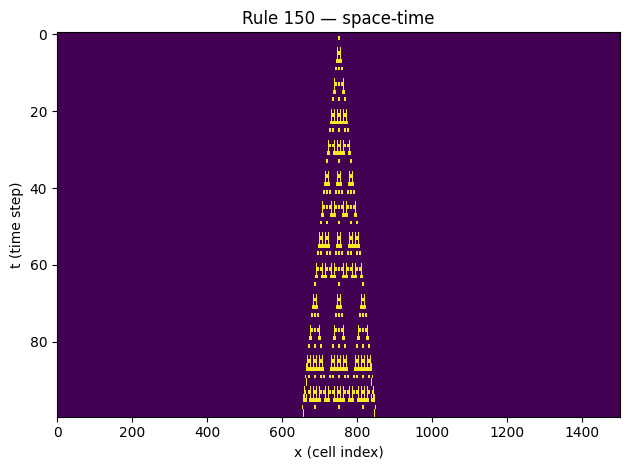

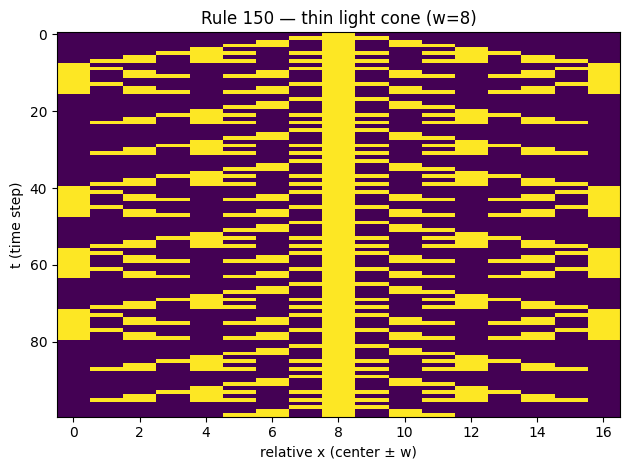

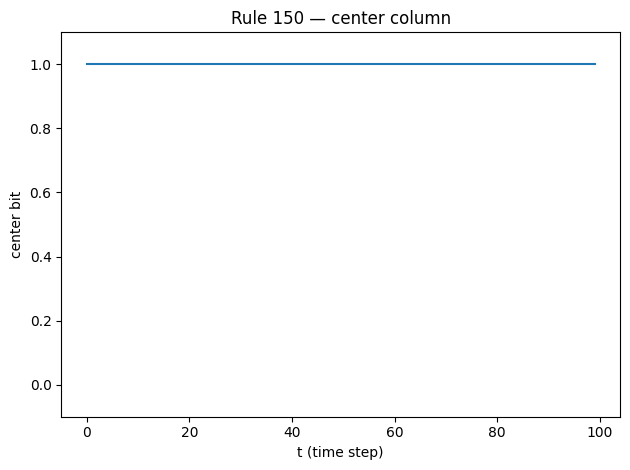

In [38]:
# Rule 150: linear/additive
grid150 = run_ca(150, width, steps, seed=2025, periodic=True, init="single")
plot_spacetime(grid150, "Rule 150 — space-time")
plot_thin_light_cone(grid150, half_width=8, title="Rule 150 — thin light cone (w=8)")
plot_center_series(grid150, title="Rule 150 — center column")


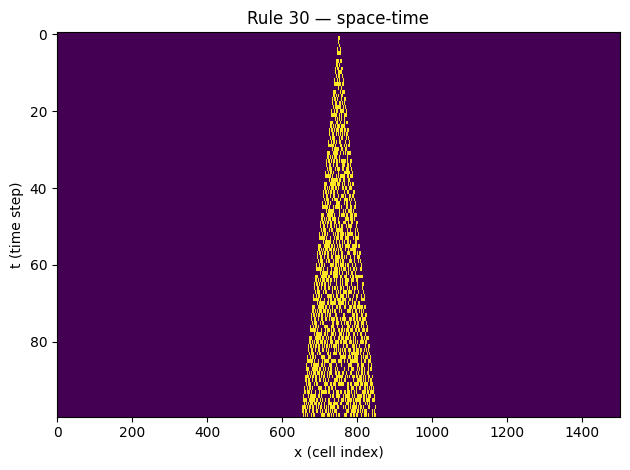

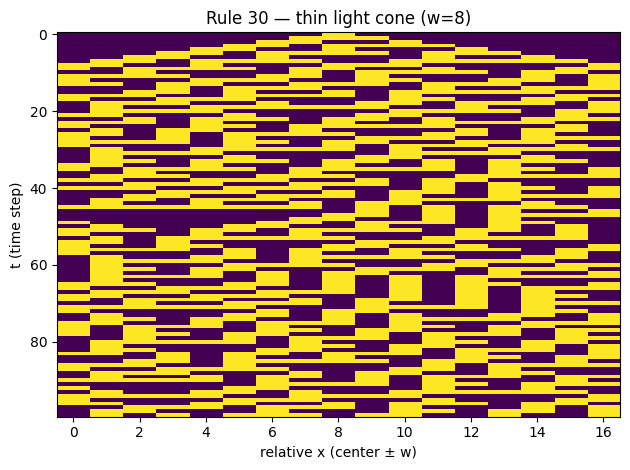

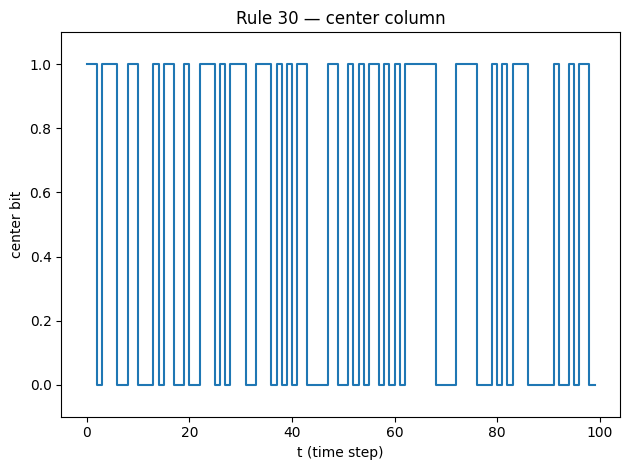

In [39]:
# Rule 30: chaotic
grid30 = run_ca(30, width, steps, seed=2026, periodic=True, init="single")
plot_spacetime(grid30, "Rule 30 — space-time")
plot_thin_light_cone(grid30, half_width=8, title="Rule 30 — thin light cone (w=8)")
plot_center_series(grid30, title="Rule 30 — center column")